In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
 83% 123M/149M [00:00<00:00, 237MB/s] 
100% 149M/149M [00:00<00:00, 220MB/s]


In [ ]:
## Extract the data
import zipfile
zip_ref = zipfile.ZipFile('/content/brain-tumor-mri-dataset.zip')
zip_ref.extractall('/content')
zip_ref.close()

##Note :::  
For practice purposes i will divide my train data into two sets validation, train and test. I will not touch the Testing Folder

In [ ]:
import os
import random
import shutil

In [ ]:
### Divide the data
source_dir = '/content/Training'
train_dir = '/content/train_data'
test_dir = '/content/test_data'
valid_dir = '/content/validation_data'

os.makedirs(train_dir, exist_ok = True)
os.makedirs(test_dir, exist_ok = True)
os.makedirs(valid_dir, exist_ok = True)

for category in os.listdir(source_dir):
  category_path = os.path.join(source_dir, category)
  if os.path.isdir(category_path):

    ## Add category subfolder for each path

    os.makedirs(os.path.join(train_dir, category), exist_ok = True)
    os.makedirs(os.path.join(test_dir, category), exist_ok = True)
    os.makedirs(os.path.join(valid_dir, category), exist_ok = True)

    ##get images for each category from original folder

    images = os.listdir(category_path)
    num_images = len(images)
    random.shuffle(images)
    train_size = int(0.7 * num_images)
    test_size = int(0.15 * num_images)
    validation_size = int(0.15 * num_images)



    train_images = images[:train_size]
    test_images = images[train_size: test_size + train_size]
    valid_images = images[train_size + test_size :]

    for file in train_images:
      shutil.move(os.path.join(category_path, file), os.path.join(train_dir, category, file))

    for file in test_images:
      shutil.move(os.path.join(category_path, file), os.path.join(test_dir, category, file))

    for file in valid_images:
      shutil.move(os.path.join(category_path, file), os.path.join(valid_dir, category, file))

    print('Done')

Done
Done
Done
Done


In [ ]:
## Preprocess the images

import tensorflow
import keras
from keras.preprocessing.image import img_to_array, array_to_img, load_img, ImageDataGenerator

In [ ]:
## Perform preprocessing and augmentation to reduce overfitting

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    zoom_range = 0.2,
    horizontal_flip = True,
    shear_range = 0.2
)

test_datagen = ImageDataGenerator(
    rescale = 1./255
)

validation_datagen = ImageDataGenerator(
    rescale = 1./255
)


trainData_generator = train_datagen.flow_from_directory(
    directory = '/content/train_data',
    target_size = (250, 250),
    batch_size = 50,
    class_mode = 'categorical'
)

test_generator = test_datagen.flow_from_directory(
    directory = '/content/test_data',
    target_size = (250, 250),
    batch_size = 50,
    class_mode = 'categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    directory = '/content/validation_data',
    target_size = (250, 250),
    batch_size = 50,
    class_mode = 'categorical'
)

Found 3996 images belonging to 4 classes.
Found 855 images belonging to 4 classes.
Found 861 images belonging to 4 classes.


<ipython-input-8-ec9e86d875ac>:15: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1, num_images, i + 1)


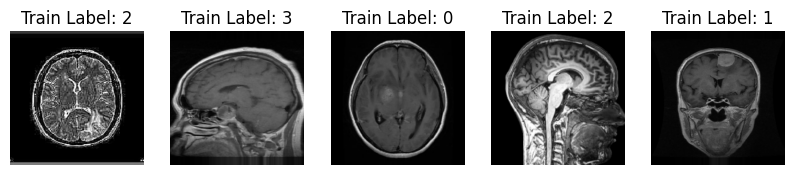

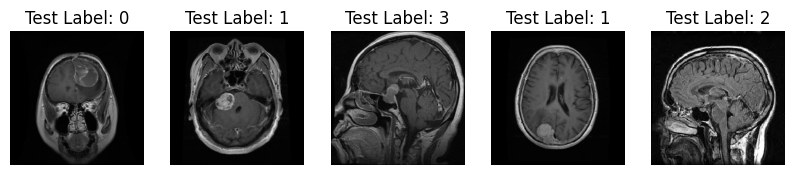

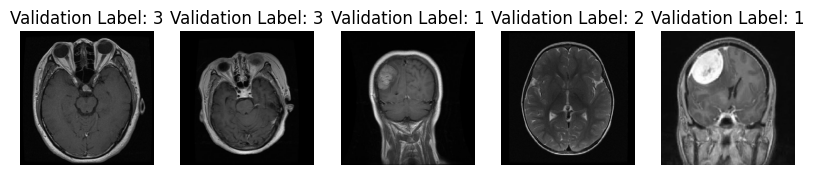

In [ ]:
###Let's Check our data now

import matplotlib.pyplot as plt
import numpy as np

def plot_images(generator, num_images=5, title = 'no'):
    # Retrieve a batch of images and labels
    batch = next(generator)
    images, labels = batch

    # Create a plot to display images
    plt.figure(figsize=(10, 15))
    plt.title(title)
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        img = images[i]  # Get the i-th image
        img = np.clip(img * 255, 0, 255).astype(np.uint8)  # Convert back to [0, 255] for visualization
        plt.imshow(img)
        plt.title(f"{title} Label: {np.argmax(labels[i])}")  # Show class label
        plt.axis('off')

    plt.show()

# Display a sample of images from the training generator
plot_images(trainData_generator, num_images=5, title = 'Train')

# Display a sample of images from the test generator
plot_images(test_generator, num_images=5, title = 'Test')

# Display a sample of images from the validation generator
plot_images(validation_generator, num_images=5, title = 'Validation')

In [ ]:
## Let's build our model

from keras.layers import MaxPooling2D, Dropout, Dense, BatchNormalization, Flatten, Conv2D
from keras.models import Sequential


In [ ]:
model = Sequential()

model.add(Conv2D(128, kernel_size= (2,2), strides = (2,2), padding = 'valid', activation = 'relu', input_shape = (250, 250, 3), name = 'conv_1'))
model.add(BatchNormalization(name = 'batch_1'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2), name = 'pool_1'))


model.add(Conv2D(128, kernel_size= (2,2), strides = (2,2), padding = 'valid', activation = 'relu', name = 'conv_2'))
model.add(BatchNormalization(name = 'batch_2'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2), name = 'pool_2'))


model.add(Conv2D(128, kernel_size= (2,2), strides = (2,2), padding = 'valid', activation = 'relu', name = 'conv_3'))
model.add(BatchNormalization(name = 'batch_3'))
model.add(MaxPooling2D(pool_size = (2,2), strides = (2,2), name = 'pool_3'))


model.add(Flatten())


model.add(Dense(256, activation = 'relu', name = 'dense_1'))
model.add(Dropout(0.2, name = 'dropout_1'))


model.add(Dense(128, activation = 'relu', name = 'dense_2'))
model.add(Dropout(0.2, name = 'dropout_2'))

model.add(Dense(4, activation = 'softmax', name = 'output_layer'))

In [ ]:
model.compile(optimizer = 'rmsprop', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
history = model.fit(trainData_generator, epochs = 20, validation_data = validation_generator)

Epoch 1/20
80/80 [==============================] - 68s 845ms/step - loss: 0.2474 - accuracy: 0.9104 - val_loss: 0.6089 - val_accuracy: 0.7816
Epoch 2/20
80/80 [==============================] - 68s 848ms/step - loss: 0.2400 - accuracy: 0.9119 - val_loss: 3.6353 - val_accuracy: 0.4437
Epoch 3/20
80/80 [==============================] - 68s 846ms/step - loss: 0.2290 - accuracy: 0.9179 - val_loss: 0.6409 - val_accuracy: 0.8049
Epoch 4/20
80/80 [==============================] - 68s 845ms/step - loss: 0.2411 - accuracy: 0.9129 - val_loss: 0.6072 - val_accuracy: 0.7793
Epoch 5/20
80/80 [==============================] - 68s 845ms/step - loss: 0.2034 - accuracy: 0.9257 - val_loss: 0.3226 - val_accuracy: 0.9071
Epoch 6/20
80/80 [==============================] - 68s 847ms/step - loss: 0.1955 - accuracy: 0.9289 - val_loss: 6.1418 - val_accuracy: 0.6109
Epoch 7/20
80/80 [==============================] - 68s 843ms/step - loss: 0.2014 - accuracy: 0.9274 - val_loss: 3.2435 - val_accuracy: 0.6492